# Fine-tuning de Gemma 4 12B pour la modération de messages

Ce notebook prépare le dataset ToxiFrench pour entraîner un modérateur francophone. À ce stade, il ne charge aucun modèle et ne lance aucun entraînement.

> L'entraînement sera réalisé directement dans VS Code/Jupyter avec **Unsloth** et son backend MLX natif pour Apple Silicon. Le notebook couvrira la préparation des données, le fine-tuning et l'évaluation.

**Checkpoint retenu :** [`unsloth/gemma-4-12b-it`](https://huggingface.co/unsloth/gemma-4-12b-it), au format Safetensors pour le fine-tuning. Les variantes `GGUF`, `NVFP4` et `bnb-4bit` ne seront pas utilisées pour l'entraînement local MLX.

## 1. Préparer et lancer l'environnement

À exécuter une seule fois dans le terminal intégré de VS Code, depuis la racine du dépôt :

```bash
cd Gemma-Moderation
uv venv .venv --python 3.12
source .venv/bin/activate
uv pip install unsloth unsloth-zoo datasets huggingface-hub pandas numpy scikit-learn matplotlib seaborn tqdm ipykernel
python -m ipykernel install --user --name gemma-moderation --display-name "Python 3.12 (Gemma Moderation)"
hf auth login
```

À chaque nouvelle session VS Code :

```bash
cd Gemma-Moderation
source .venv/bin/activate
```

Sélectionner ensuite le kernel **Python 3.12 (Gemma Moderation)** en haut à droite du notebook.

## 2. Imports et dépendances

Les bibliothèques sont regroupées par usage : données, visualisation, évaluation et fine-tuning avec Unsloth sur MLX.

In [2]:
# Bibliothèque standard
import json
import os
import random
from pathlib import Path

# Manipulation et visualisation des données
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# Hugging Face : dataset et authentification
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import login

# Évaluation du modérateur
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

# Backend Apple Silicon
import mlx.core as mx

# API publique Unsloth ; le backend MLX est détecté automatiquement sur Mac
from unsloth import (
    FastModel,
    UnslothTrainer,
    UnslothTrainingArguments,
    is_bfloat16_supported,
)
from datasets import concatenate_datasets

/Users/elouan/Documents/Finetuning-learning/Gemma-Moderation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/elouan/Documents/Finetuning-learning/Gemma-Moderation/.venv/lib/python3.12/site-packages/trl/extras/best_of_n_sampler.py:24: FutureWarning: `BestOfNSampler` is deprecated and will be removed in TRL 0.25.
  class BestOfNSampler:


## 3. Chargement du dataset ToxiFrench

Le dataset est téléchargé depuis Hugging Face et conservé au format `DatasetDict`.

In [5]:
from datasets import load_dataset

dataset = load_dataset("AxelDlv00/ToxiFrench")

## 4. Construction d'un échantillon équilibré

Un subset de 1 000 messages, composé de 500 exemples par classe, permet de valider rapidement le pipeline sans modifier le dataset original.

In [9]:
train_data = dataset["train"]
label_column = "literal_conclusion_annotator"

oui = train_data.filter(lambda row: row[label_column] == "oui")
non = train_data.filter(lambda row: row[label_column] == "non")

small_train = concatenate_datasets([
      oui.shuffle(seed=42).select(range(2148)),
      non.shuffle(seed=42).select(range(2148)),
  ]).shuffle(seed=42)

display(small_train[:5])

{'msg_id': ['anon_msg_46b60ae51130',
  'anon_msg_00a7017affed',
  'anon_msg_24a5eedc4834',
  'anon_msg_26a2c0af5750',
  'anon_msg_4296f33cbaae'],
 'content': ['Je vais lâcher la semence sur ton visage',
  "Je sais pas si je suis débile mais j'ai absolument rien compris.\nL'op va en zonzon pour des story insta ?",
  'Ayaaa reste à ta place de soufifre le rageux\n:hap:',
  "Ahi aucun belge ici présent\nBordelent en une heure tu t'es transformer kheyax, va molo\nÉdit ; j'avais pas vu le truc boomer mb",
  '947\nJe suis pas ton pote le puceau'],
 'literal_conclusion_annotator': ['oui', 'non', 'oui', 'non', 'oui'],
 'CoT_explication': ["<think>\nExplication :\n**Sujet du message** : Une expression suggestive et potentiellement vulgaire.\n\n**Résumé** : L'auteur annonce son intention de projeter du liquide (possiblement non spécifié) sur le visage d'une personne.\n\n**Sens probable** : Cela peut se rapporter à une connotation sexuelle ou agressive, bien que l'interprétation exacte dépende du

## 5. Exploration et contrôle des données

### 5.1 Structure et aperçu

In [10]:
display(small_train.column_names)


['msg_id',
 'content',
 'literal_conclusion_annotator',
 'CoT_explication',
 'CoT_tons',
 'CoT_intentions',
 'CoT_categorie',
 'CoT_labels',
 'CoT_score',
 'cot_final_question',
 'direct_question']

### 5.2 Conversion temporaire en DataFrame

In [11]:
df = small_train.to_pandas()

print(f"Nombre de lignes : {len(df)}")
print("Colonnes :", df.columns.tolist())
display(df.head())

Nombre de lignes : 4296
Colonnes : ['msg_id', 'content', 'literal_conclusion_annotator', 'CoT_explication', 'CoT_tons', 'CoT_intentions', 'CoT_categorie', 'CoT_labels', 'CoT_score', 'cot_final_question', 'direct_question']


,msg_id,content,literal_conclusion_annotator,CoT_explication,CoT_tons,CoT_intentions,CoT_categorie,CoT_labels,CoT_score,cot_final_question,direct_question
0,anon_msg_46b60ae51130,Je vais lâcher la semence sur ton visage,oui,<think>\nExplication :\n**Sujet du message** :...,"<think>\nTons :\nTons perçus : Provocateur, Vu...",<think>\nIntentions :\n**Intentions principale...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H2/V0/R0/A2/I2\n\nJustif...,<think>\nScore de toxicité :\n7/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
1,anon_msg_00a7017affed,Je sais pas si je suis débile mais j'ai absolu...,non,<think>\nExplication :\n**Sujet du message** :...,<think>\nTons :\nTons identifiés : \n\n1. **Co...,<think>\nIntentions :\n1. **Exprimer l'incompr...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n2/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
2,anon_msg_24a5eedc4834,Ayaaa reste à ta place de soufifre le rageux\n...,oui,<think>\nExplication :\n- **Sujet du message**...,<think>\nTons :\nTons perçus :\n1. **Moqueur**...,<think>\nIntentions :\n**Intentions identifiée...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS1/H0/V0/R0/A1/I1\n\nJustif...,<think>\nScore de toxicité :\n6/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
3,anon_msg_26a2c0af5750,Ahi aucun belge ici présent\nBordelent en une ...,non,<think>\nExplication :\n**Sujet du message** :...,<think>\nTons :\nTons identifiés :\n\n1. **Amu...,<think>\nIntentions :\n**Intentions du message...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n1/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
4,anon_msg_4296f33cbaae,947\nJe suis pas ton pote le puceau,oui,<think>\nExplication :\n- **Sujet du message**...,<think>\nTons :\nLes tons perçus dans le messa...,<think>\nIntentions :\nLe message présente plu...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A2/I1\n\nJustif...,<think>\nScore de toxicité :\n5/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?


### 5.3 Répartition des labels

In [12]:
label_column = "literal_conclusion_annotator"

display(df[label_column].value_counts(dropna=False))
display(df[label_column].value_counts(normalize=True, dropna=False))

literal_conclusion_annotator
oui    2148
non    2148
Name: count, dtype: int64

literal_conclusion_annotator
oui    0.5
non    0.5
Name: proportion, dtype: float64

### 5.4 Qualité et longueur des messages

Valeurs manquantes :


content                         0
literal_conclusion_annotator    0
dtype: int64

Textes dupliqués : 2
Textes vides : 0


count    4296.000000
mean       74.093575
std        38.378849
min        16.000000
25%        45.000000
50%        70.000000
75%        99.000000
max      1333.000000
Name: character_count, dtype: float64

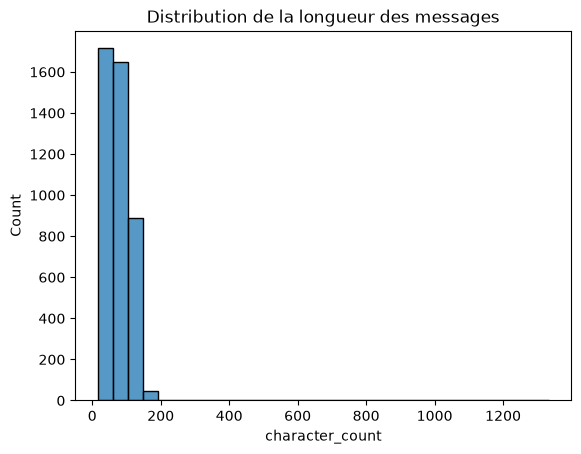

In [13]:
print("Valeurs manquantes :")
display(df[["content", label_column]].isna().sum())

print("Textes dupliqués :", df["content"].duplicated().sum())
print("Textes vides :", df["content"].fillna("").str.strip().eq("").sum())

df["character_count"] = df["content"].fillna("").str.len()

display(df["character_count"].describe())

sns.histplot(df["character_count"], bins=30)
plt.title("Distribution de la longueur des messages")
plt.show()

## 6. Normalisation des labels

Les valeurs `oui` et `non` sont converties en labels numériques et textuels tout en conservant l'annotation d'origine.

### 6.1 Création des labels normalisés

In [15]:
label_mapping = {
      "non": 0,
      "oui": 1,
  }

label_names = {
      0: "non_toxique",
      1: "toxique",
  }

def normalize_label(example):
      raw_label = example["literal_conclusion_annotator"].strip().lower()
      label = label_mapping[raw_label]

      return {
          "label": label,
          "label_text": label_names[label],
      }

small_train = small_train.map(normalize_label)

Map: 100%|██████████| 4296/4296 [00:00<00:00, 22396.34 examples/s]


### 6.2 Vérification des labels

In [16]:
print(small_train.column_names)
print(small_train[0])

small_train.to_pandas()[["label", "label_text"]].value_counts()

['msg_id', 'content', 'literal_conclusion_annotator', 'CoT_explication', 'CoT_tons', 'CoT_intentions', 'CoT_categorie', 'CoT_labels', 'CoT_score', 'cot_final_question', 'direct_question', 'label', 'label_text']
{'msg_id': 'anon_msg_46b60ae51130', 'content': 'Je vais lâcher la semence sur ton visage', 'literal_conclusion_annotator': 'oui', 'CoT_explication': "<think>\nExplication :\n**Sujet du message** : Une expression suggestive et potentiellement vulgaire.\n\n**Résumé** : L'auteur annonce son intention de projeter du liquide (possiblement non spécifié) sur le visage d'une personne.\n\n**Sens probable** : Cela peut se rapporter à une connotation sexuelle ou agressive, bien que l'interprétation exacte dépende du contexte. Côté certitude : élevé pour l'intention provocante.\n</think>", 'CoT_tons': "<think>\nTons :\nTons perçus : Provocateur, Vulgaire, Agressif.\n\nJustification : Le message exprime une intention d'humiliation ou de dédain, avec une connotation sexuelle. Certitude élevée

label  label_text 
1      toxique        2148
0      non_toxique    2148
Name: count, dtype: int64

## 7. Séparation des données

Le subset est séparé en **80 % d'entraînement** et **20 % de validation**. La stratification conserve la même proportion de messages toxiques et non toxiques dans chaque ensemble.

### 7.1 Création des splits

In [18]:
indices = np.arange(len(small_train))

train_indices, validation_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=small_train["label"],
)

train_dataset = small_train.select(train_indices.tolist())
validation_dataset = small_train.select(validation_indices.tolist())
display(validation_dataset[0])

{'msg_id': 'anon_msg_ea08e1a10b9f',
 'content': "France c'est foireux, je crois à la malédiction des champions du monde. C'est pareil à chaque édition.",
 'literal_conclusion_annotator': 'non',
 'CoT_explication': "<think>\nExplication :\n- **Sujet du message** : Lamentation sur la performance des champions du monde en France.\n- **Sens probable** : L'auteur exprime son scepticisme concernant la réussite de l’équipe de France, suggérant qu’une sorte de malédiction affecte les champions après leur victoire.\n</think>",
 'CoT_tons': '<think>\nTons :\nTons perçus :  \n1. **Cynique** (certitude élevée) : L\'emploi du terme "foireux" et l\'idée de "malédiction" suggèrent un désenchantement envers l\'équipe de France.\n2. **Lamentatif** (certitude modérée) : La mention de la répétition de cette situation indique une frustration face aux performances.\n3. **Défaitiste** (certitude modérée) : L’expression "je crois" laisse transparaître un manque d\'espoir pour l\'avenir.\n\nDoutes : L\'analys

### 7.2 Vérification de la séparation

In [19]:
print(f"Entraînement : {len(train_dataset)} exemples")
print(pd.Series(train_dataset["label_text"]).value_counts())

print(f"\nValidation : {len(validation_dataset)} exemples")
print(pd.Series(validation_dataset["label_text"]).value_counts())

Entraînement : 3436 exemples
toxique        1718
non_toxique    1718
Name: count, dtype: int64

Validation : 860 exemples
non_toxique    430
toxique        430
Name: count, dtype: int64


## 8. Format d'entraînement prompt/completion

Chaque exemple est séparé en un `prompt` (système et utilisateur) et une `completion` (assistant). Ce découpage permet à `completion_only_loss=True` de masquer explicitement le prompt et d'entraîner le modèle uniquement sur le JSON attendu. Les raisons sont ramenées à un vocabulaire court et contrôlé pour réduire le bruit des colonnes `CoT_*`.

### 8.1 Création des exemples formatés

In [20]:
CONTROLLED_REASONS = [
    "présence d'une insulte",
    "attaque personnelle",
    "incitation à la violence",
    "propos discriminatoire",
    "contenu sexuel explicite",
    "contenu offensant ou nuisible",
    "aucun élément toxique détecté",
]

SYSTEM_PROMPT = (
    "Tu es un modérateur francophone. Analyse le message et réponds uniquement "
    "avec un JSON valide contenant les clés 'label' et 'reason'. "
    "Le label doit être 'toxique' ou 'non_toxique'. La raison doit être "
    f"une valeur courte parmi : {', '.join(CONTROLLED_REASONS)}."
)

REASON_RULES = [
    ("incitation à la violence", ("violence", "incit", "menace", "tuer", "tirer", "nuire")),
    ("propos discriminatoire", ("racis", "discrimin", "xénoph", "homophob", "sexiste", "origine", "ethni")),
    ("contenu sexuel explicite", ("sexuel", "pornograph", "obscène")),
    ("attaque personnelle", ("attaque personnelle", "harcèl", "humili")),
    ("présence d'une insulte", ("insult", "injur", "mépris", "péjoratif", "grossier")),
]

def build_controlled_reason(example):
    if example["label_text"] == "non_toxique":
        return "aucun élément toxique détecté"

    analysis_text = " ".join(
        str(example.get(column, ""))
        for column in ("CoT_score", "CoT_intentions", "CoT_categorie")
    ).lower()

    for reason, keywords in REASON_RULES:
        if any(keyword in analysis_text for keyword in keywords):
            return reason

    return "contenu offensant ou nuisible"

def format_for_training(example):
    assistant_response = json.dumps(
        {
            "label": example["label_text"],
            "reason": build_controlled_reason(example),
        },
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["content"]},
        ],
        "completion": [
            {"role": "assistant", "content": assistant_response},
        ],
    }

formatted_train_dataset = (
    train_dataset
    .map(format_for_training)
    .select_columns(["prompt", "completion"])
)

formatted_validation_dataset = (
    validation_dataset
    .map(format_for_training)
    .select_columns(["prompt", "completion"])
)

Map: 100%|██████████| 860/860 [00:00<00:00, 23395.09 examples/s]


### 8.2 Vérification du format

In [21]:
display({
    "prompt": formatted_train_dataset[0]["prompt"],
    "completion": formatted_train_dataset[0]["completion"],
})

print("Colonnes entraînement :", formatted_train_dataset.column_names)
print("Colonnes validation :", formatted_validation_dataset.column_names)

{'prompt': [{'role': 'system',
   'content': "Tu es un modérateur francophone. Analyse le message et réponds uniquement avec un JSON valide contenant les clés 'label' et 'reason'. Le label doit être 'toxique' ou 'non_toxique'. La raison doit être une valeur courte parmi : présence d'une insulte, attaque personnelle, incitation à la violence, propos discriminatoire, contenu sexuel explicite, contenu offensant ou nuisible, aucun élément toxique détecté."},
  {'role': 'user', 'content': 'Mais quelle grosse beurette de merde\n:rire:'}],
 'completion': [{'role': 'assistant',
   'content': '{"label":"toxique","reason":"attaque personnelle"}'}]}

Colonnes entraînement : ['prompt', 'completion']
Colonnes validation : ['prompt', 'completion']


## 9. Chargement de Gemma 4 12B

Le checkpoint instruction-tuned publié par Unsloth est chargé en 4 bits pour limiter l'utilisation de la mémoire unifiée. Le premier lancement télécharge les poids du modèle.

### 9.1 Chargement du checkpoint

In [22]:
MODEL_NAME = "unsloth/gemma-4-12b-it"
MAX_SEQ_LENGTH = 2048

model, tokenizer = FastModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 1948.25it/s]
You are using a model of type `gemma4_unified` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Unsloth: Loading unsloth/gemma-4-12b-it via mlx-vlm (VLM, runtime 4-bit affine quantization)...


You are using a model of type `gemma4_unified` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[INFO] Quantized model with 5.497 bits per weight.


## 10. Évaluation de la baseline

Cette évaluation mesure les performances du modèle avant le fine-tuning. La réponse attendue n'est jamais incluse dans le prompt envoyé au modèle.

### 10.1 Fonction de modération

In [23]:
def moderate(message):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": message},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="np",
    )

    prompt_length = inputs["input_ids"].shape[-1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
    )

    decoder = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
    generated_tokens = outputs[0][prompt_length:]

    return decoder.decode(
        generated_tokens.tolist(),
        skip_special_tokens=True,
    ).strip()

### 10.2 Test manuel

Commencer par un exemple permet de vérifier le prompt et le format de sortie avant de lancer les 200 générations.

In [24]:
example = validation_dataset[0]

print("Message :", example["content"])
print("Réponse attendue :", example["label_text"])
print("Réponse de Gemma :", moderate(example["content"]))

Message : France c'est foireux, je crois à la malédiction des champions du monde. C'est pareil à chaque édition.
Réponse attendue : non_toxique
Réponse de Gemma : ```json
{
  "label": "non_toxique",
  "reason": "aucun élément toxique détecté"
}
```


### 10.3 Lecture du label JSON

Les réponses non conformes au schéma demandé sont conservées sous le label `format_invalide` afin de ne pas masquer les erreurs du modèle.

In [25]:
def parse_label(response):
    start = response.find("{")
    end = response.rfind("}") + 1

    if start == -1 or end == 0:
        return "format_invalide"

    try:
        result = json.loads(response[start:end])
        label = result.get("label")

        if label in {"toxique", "non_toxique"}:
            return label
    except json.JSONDecodeError:
        pass

    return "format_invalide"

### 10.4 Test sur les 200 exemples

La barre `tqdm` affiche l'avancement. Cette boucle peut prendre du temps avec un modèle de 12 milliards de paramètres.

In [18]:
results = []

for example in tqdm(
    validation_dataset,
    total=len(validation_dataset),
    desc="Évaluation",
):
    raw_response = moderate(example["content"])

    results.append({
        "content": example["content"],
        "expected": example["label_text"],
        "predicted": parse_label(raw_response),
        "raw_response": raw_response,
    })

results_df = pd.DataFrame(results)
display(results_df.head())

Évaluation: 100%|██████████| 200/200 [04:31<00:00,  1.36s/it]


,content,expected,predicted,raw_response
0,Tu peux chialer un peu plus fort stp le cuck ?,toxique,toxique,"```json\n{\n ""label"": ""toxique"",\n ""reason"":..."
1,C'est le champion il fait ce qu'il veut,non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
2,Haha ma foi c'est déjà ça de pris !,non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
3,"C est pourtant simple, ils sont toujours là en...",non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
4,CHEH pour ses voitures LGBTQIA++++,toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."


### 10.5 Rapport de classification

La précision, le rappel et le F1-score sont plus informatifs que l'accuracy seule pour un problème de modération.

In [20]:
print(
    classification_report(
        results_df["expected"],
        results_df["predicted"],
        labels=["non_toxique", "toxique"],
        zero_division=0,
    )
)

print(
    "Formats invalides :",
    (results_df["predicted"] == "format_invalide").sum(),
)

              precision    recall  f1-score   support

 non_toxique       0.84      0.94      0.89       100
     toxique       0.93      0.82      0.87       100

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200

Formats invalides : 0


### 10.6 Matrice de confusion

La matrice permet de distinguer rapidement les faux positifs des faux négatifs.

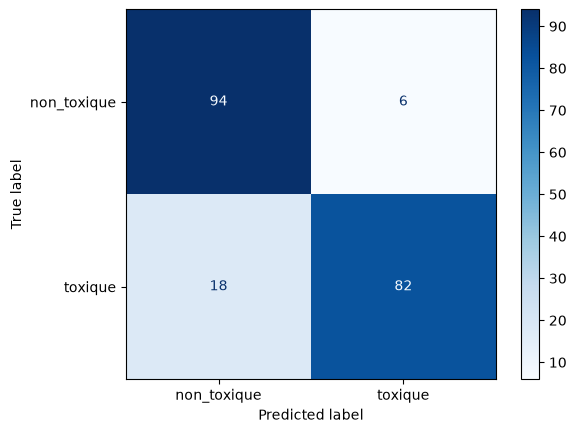

In [21]:
ConfusionMatrixDisplay.from_predictions(
    results_df["expected"],
    results_df["predicted"],
    labels=["non_toxique", "toxique"],
    cmap="Blues",
)

plt.show()

## 11. Adaptateurs QLoRA

Les adaptateurs LoRA sont ajoutés aux couches d'attention et aux couches MLP du modèle de langage. Le modèle principal reste quantifié et gelé ; seules les matrices LoRA sont entraînables. Les composants vision et projecteur restent désactivés pour ce projet textuel.

### 11.1 Ajout des adaptateurs

In [26]:
model = FastModel.get_peft_model(
      model,
      r=8,
      target_modules=[
          "q_proj",
          "k_proj",
          "v_proj",
          "o_proj",
          "gate_proj",
          "up_proj",
          "down_proj",
      ],
      lora_alpha=8,
      lora_dropout=0,
      use_gradient_checkpointing="mlx",
      random_state=42,
      train_vision=False,
      train_projector=False,
      finetune_language_layers=True,
  )

Unsloth: LoRA applied — 32,784,384 trainable params (1.18% of 2,773,289,008 total)


## 12. Smoke test QLoRA

Ce premier entraînement utilise seulement 50 exemples et 5 étapes. Son objectif est de valider le pipeline, la mémoire et la stabilité de la loss avant l'entraînement sur les 800 exemples.

### 12.1 Création du subset de test

In [85]:
smoke_train_dataset = (
      formatted_train_dataset
      .shuffle(seed=42)
      .select(range(50))
  )

### 12.2 Configuration de l'entraînement

Les colonnes `prompt` et `completion` sont détectées automatiquement par le trainer. Avec `completion_only_loss=True`, la loss est calculée uniquement sur la réponse de l'assistant.

In [87]:
smoke_args = UnslothTrainingArguments(
    output_dir="outputs/smoke_test",
    max_seq_length=512,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=5,
    warmup_steps=1,
    learning_rate=2e-4,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    completion_only_loss=True,
    logging_steps=1,
    save_steps=0,
    seed=42,
    report_to="none",
)

### 12.3 Création du trainer

In [88]:
smoke_trainer = UnslothTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=smoke_train_dataset,
    args=smoke_args,
)

### 12.4 Lancement du smoke test

La première étape peut être plus longue en raison de la compilation MLX. Vérifier l'absence de `NaN` et d'erreur mémoire, ainsi que l'évolution de la loss.

In [89]:
smoke_result = smoke_trainer.train()

Unsloth: Casting MLX norm outputs back to activation dtype.
Unsloth: MLX Metal memory guard enabled (memory_limit=34.17 GB, wired_limit=34.17 GB).
Unsloth: Using gradient checkpointing to reduce memory.
Unsloth: Masking 9 image token IDs from VLM loss.
Unsloth: VLM CCE skipping weight gradient (LM head is frozen).
Unsloth: Using VLM CCE loss (runtime-cce) for memory-efficient training.
Unsloth: audio modules kept frozen during training (embed_audio).
Unsloth: mx.compile disabled for VLM arch 'gemma4_unified' during training; using eager mode (compile blockers detected: data_to_python, mutable_model_state, ragged_python_control_flow (backends=gemma4_unified_text,gemma4_unified_audio,gemma4_unified_vision)).
Unsloth: Compile trace summary:
  arch=gemma4_unified
  patch_mode=patched
  support_state=unsupported
  verification_state=pattern_candidate
  decision=best_effort:disabled
  decision_reason=compile blockers detected: data_to_python, mutable_model_state, ragged_python_control_flow (

## 13. Entraînement QLoRA complet

L'entraînement utilise les 800 exemples du split d'entraînement pendant une époque.

### 13.1 Configuration

In [27]:
training_args = UnslothTrainingArguments(
      output_dir="outputs/gemma_moderation_qlora",
      max_seq_length=512,

      per_device_train_batch_size=1,
      gradient_accumulation_steps=4,
      num_train_epochs=1,

      warmup_ratio=0.05,
      learning_rate=1e-4,
      weight_decay=0.01,
      lr_scheduler_type="linear",

      eval_steps=100,

      completion_only_loss=True,
      gradient_checkpointing=True,
      compile=False,

      logging_steps=5,
      save_steps=100,
      save_total_limit=2,
      seed=42,
      report_to="none",
      load_best_model_at_end=True,
  )

### 13.2 Lancement de l'entraînement

In [ ]:
trainer = UnslothTrainer(
      model=model,
      processing_class=tokenizer,
      train_dataset=formatted_train_dataset,
      eval_dataset=formatted_validation_dataset,
      args=training_args,
  )

training_result = trainer.train()

Unsloth: Casting MLX norm outputs back to activation dtype.
Unsloth: MLX Metal memory guard enabled (memory_limit=34.17 GB, wired_limit=34.17 GB).
Unsloth: Using gradient checkpointing to reduce memory.
Unsloth: Masking 9 image token IDs from VLM loss.
Unsloth: VLM CCE skipping weight gradient (LM head is frozen).
Unsloth: Using VLM CCE loss (runtime-cce) for memory-efficient training.
Unsloth: audio modules kept frozen during training (embed_audio).
Unsloth: Training for 200 steps, BS=1, grad_accum=4, seq_len=512
Unsloth: Features: VLM, CCE, GC, compile=unsupported, LR=linear, opt=adamw
Unsloth: Compile recommendations:
  - compile=False: Compile should stay disabled for this run (compile disabled by policy).
  Step 5/200 | Loss: 3.2363 | Grad: 8.9276 | LR: 8.00e-05 | Tok/s: 10 | Peak: 12.36 GB
  Step 10/200 | Loss: 0.6413 | Grad: 1.9371 | LR: 1.80e-04 | Tok/s: 10 | Peak: 12.57 GB
  Step 15/200 | Loss: 0.0972 | Grad: 0.8825 | LR: 1.96e-04 | Tok/s: 11 | Peak: 12.58 GB
  Step 20/200 | L

## 14. Évaluation après fine-tuning

Les nouveaux résultats utilisent des variables distinctes afin de préserver la baseline. Les deux jeux de prédictions sont également sauvegardés sur le disque.

### 14.1 Conservation de la baseline

In [30]:
evaluation_dir = Path("outputs/evaluations")
evaluation_dir.mkdir(parents=True, exist_ok=True)

baseline_results_df = results_df.copy()
baseline_results_df.to_csv(
    evaluation_dir / "baseline_results.csv",
    index=False,
)

### 14.2 Prédictions sur les 200 exemples

Le modèle actuellement en mémoire contient les adaptateurs entraînés. La validation reste strictement identique à celle de la baseline.

In [26]:
finetuned_results = []

for example in tqdm(
    validation_dataset,
    total=len(validation_dataset),
    desc="Évaluation après fine-tuning",
):
    raw_response = moderate(example["content"])

    finetuned_results.append({
        "content": example["content"],
        "expected": example["label_text"],
        "predicted": parse_label(raw_response),
        "raw_response": raw_response,
    })

finetuned_results_df = pd.DataFrame(finetuned_results)
finetuned_results_df.to_csv(
    evaluation_dir / "finetuned_results.csv",
    index=False,
)

display(finetuned_results_df.head())

Évaluation après fine-tuning: 100%|██████████| 200/200 [06:40<00:00,  2.00s/it]


,content,expected,predicted,raw_response
0,Tu peux chialer un peu plus fort stp le cuck ?,toxique,toxique,"{""label"":""toxique"",""reason"":""incitation à la v..."
1,C'est le champion il fait ce qu'il veut,non_toxique,non_toxique,"{""label"":""non_toxique"",""reason"":""aucun élément..."
2,Haha ma foi c'est déjà ça de pris !,non_toxique,non_toxique,"{""label"":""non_toxique"",""reason"":""aucun élément..."
3,"C est pourtant simple, ils sont toujours là en...",non_toxique,non_toxique,"{""label"":""non_toxique"",""reason"":""aucun élément..."
4,CHEH pour ses voitures LGBTQIA++++,toxique,toxique,"{""label"":""toxique"",""reason"":""incitation à la v..."


### 14.3 Rapport de classification

In [27]:
print(
    classification_report(
        finetuned_results_df["expected"],
        finetuned_results_df["predicted"],
        labels=["non_toxique", "toxique"],
        zero_division=0,
    )
)

print(
    "Formats invalides :",
    (finetuned_results_df["predicted"] == "format_invalide").sum(),
)

              precision    recall  f1-score   support

 non_toxique       0.97      0.83      0.89       100
     toxique       0.85      0.97      0.91       100

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.90      0.90       200

Formats invalides : 0


### 14.4 Matrice de confusion

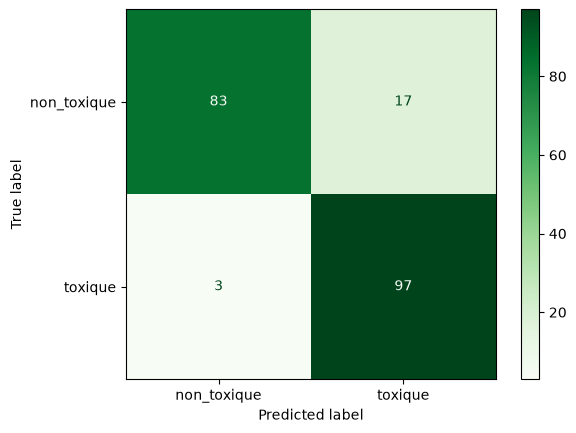

In [28]:
ConfusionMatrixDisplay.from_predictions(
    finetuned_results_df["expected"],
    finetuned_results_df["predicted"],
    labels=["non_toxique", "toxique"],
    cmap="Greens",
)

plt.show()

### 14.5 Comparaison avant et après fine-tuning

Ce tableau compare les métriques de la classe `toxique`, prioritaire pour limiter les messages dangereux non détectés.

In [31]:
baseline_report = classification_report(
    baseline_results_df["expected"],
    baseline_results_df["predicted"],
    labels=["non_toxique", "toxique"],
    zero_division=0,
    output_dict=True,
)

finetuned_report = classification_report(
    finetuned_results_df["expected"],
    finetuned_results_df["predicted"],
    labels=["non_toxique", "toxique"],
    zero_division=0,
    output_dict=True,
)

comparison_df = pd.DataFrame({
    "baseline": baseline_report["toxique"],
    "après_finetuning": finetuned_report["toxique"],
})
comparison_df["écart"] = (
    comparison_df["après_finetuning"] - comparison_df["baseline"]
)

display(comparison_df)

,baseline,après_finetuning,écart
precision,0.931818,0.850877,-0.080941
recall,0.820000,0.970000,0.150000
f1-score,0.872340,0.906542,0.034202
support,100.000000,100.000000,0.000000


## 15. Sauvegarde et publication sur Hugging Face

Cette section sauvegarde les adaptateurs LoRA et les publie dans un dépôt de modèles Hugging Face. Le token d'authentification ne doit jamais être écrit directement dans le notebook.